#### 패션 MNIST
- 구두, 가방, 옷 등의 이미지로 구성
- 총 10개 class
- 28pixel * 28 pixel = 784개의 Feature로 구성
- Sample수는 70000개

In [ ]:
# !pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 7.1/351.2 MB 35.6 MB/s eta 0:00:10
   - -------------------------------------- 11.5/351.2 MB 40.8 MB/s eta 0:00:09
   - -------------------------------------- 11.5/351.2 MB 40.8 MB/s eta 0:00:09
   - -------------------------------------- 13.1/351.2 MB 16.0 MB/s eta 0:00:22
   -- ------------------------------------- 17.8/351.2 MB 19.1 MB/s eta 0:00:18
   --- ------------------------------------ 26.7/351.2 MB 21.6 MB/s eta 0:00:16
   ---- ----------------------------------- 36.2/351.2 MB 25.1 MB/s eta 0:00:13
   ----- ---------------------------------- 45.9/351.2 MB 28.0 MB/s eta 0:00:11
   ------ --------------------------------- 53.5/351.2 MB 29.1 MB/s eta 0:00:11
   ------ --------------------------------- 61.1/351.2 MB 29.7 MB/s eta 0:00:10
   ------- -------------------------------- 66.1/351.2 MB 30.2 MB/s eta 0:00:10
   ------- -------------------------------- 66.1/3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [ ]:
# 데이터 불러오기
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

In [12]:
# traindata
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [15]:
# testdata
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [14]:
train_target[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

0 : 티셔츠 1: 바지 2:스웨터 3:드레스 4:코트 5:샌달 6:셔츠 7:스니커즈 8:가방 9:앵글부츠

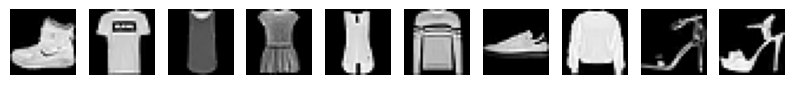

In [16]:
# train_input의 모양 10개만 출력
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray')
    axs[i].axis('off')

plt.show()

In [18]:
# train_target의 종류 및 갯수 파악
import numpy as np

np.unique(train_target, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

----
#### 로지스틱 회귀 모델

In [20]:
# 데이터 표준화 및 2차 행렬로 만들기
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)
train_scaled.shape

(60000, 784)

In [21]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(
    loss='log_loss',
    max_iter=5,
    random_state=42
)

scores = cross_validate(
    sc,
    train_scaled,
    train_target,
    n_jobs=-1
)
print("평균 :", np.mean(scores['test_score']))

평균 : 0.81945


----
#### 인공신경망

In [22]:
# Train Data를 훈련데이터와 검증 데이터로 나누기
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )


In [25]:
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [26]:
from tensorflow.keras.layers import Input
model = keras.Sequential()
model.add(Input(shape=(784,)))
model.add(keras.layers.Dense(10, activation="softmax")) # sigmoid

In [32]:
# 손실함수
history = model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [38]:
# 모델 훈련 
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 881us/step - accuracy: 0.8656 - loss: 0.4008
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - accuracy: 0.8667 - loss: 0.3992
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step - accuracy: 0.8665 - loss: 0.3983
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 993us/step - accuracy: 0.8666 - loss: 0.3966
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.8664 - loss: 0.3965


In [39]:
# 검증 데이터로 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.8538 - loss: 0.4378


[0.4377821087837219, 0.8538333177566528]